# Introducción a la Ciencia de Datos: Tarea 1

Este notebook contiene el código de base para realizar la Tarea 1 del curso. Puede copiarlo en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd).

Se utiliza el lenguaje Python y la librería Pandas. Si no tiene ninguna familiaridad con la librería, se recomienda realizar algún tutorial introductorio (ver debajo).
También se espera que los alumnos sean proactivos a la hora de consultar las documentaciones de las librerías y del lenguaje, para entender el código provisto.
Además de los recursos provistos en la [página del curso](https://eva.fing.edu.uy/course/view.php?id=1378&section=1), los siguientes recursos le pueden resultar interesantes:
 - [Pandas getting started](https://pandas.pydata.org/docs/getting_started/index.html#getting-started) y [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html): Son parte de la documentación en la página oficial de Pandas.
 - [Kaggle Learn](https://www.kaggle.com/learn): Incluye tutoriales de Python y Pandas.


Si desea utilizar el lenguaje R y está dispuesto a no utilizar (o traducir) este código de base, también puede hacerlo.

En cualquier caso, **se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://github.com/DonBraulio/introCD)).

In [2]:
from time import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from datasets import load_dataset

# Agregue aqui el resto de las librerias que necesite
# from ...
# import ...

## Descarga del dataset
En esta tarea se utilizará una base de datos abierta que contiene artículos de noticias publicados en distintos medios de prensa, con la finalidad de realizar una clasificación de textos según el medio de prensa al que pertenecen. [Link](https://huggingface.co/datasets/rjac/all-the-news-2-1-Component-one?utm_source=chatgpt.com) \
\
Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas. La constante `DATA_PATH` determina la ubicación donde se almacenaran los datos. \
\
El dataset entero pesa ~8.3gb. Para evitar demoras en la descarga/procesamiento vamos a utilizar el parámetro `streaming=True` y hacer un muestreo aleatorio para descargar una porción de los datos lo más representativa posible.

In [3]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", split="train",cache_dir="../data")
df = ds.to_pandas()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


all-the-news-2-1-Component-ones-cluster-(…):   0%|          | 0.00/60.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/30213 [00:00<?, ? examples/s]

## Lectura de Datos

In [ ]:
# Veamos las primeras filas del DataFrame
df.head()

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,1,1,2018-02-02,2018,2.0,2,None,BRIEF-Teva Says Fremanezumab Marketing Authori...,Feb 2 (Reuters) - Teva Pharmaceutical Industri...,https://www.reuters.com/article/brief-teva-say...,Healthcare,Reuters
1,2,2,2018-05-01,2018,5.0,1,None,CMS' Verma says it’s time health care caught u...,The head of the Centers for Medicare and Medic...,https://www.cnbc.com/2018/04/30/cms-verma-says...,Health and Science,CNBC
2,3,3,2017-08-14,2017,8.0,14,Harper Neidig,Uber investor accuses Kalanick of 'undermining...,"Benchmark, the venture capital firm that helpe...",https://thehill.com/policy/technology/346520-u...,None,The Hill
3,4,4,2017-04-03 00:00:00,2017,4.0,3,None,Chad Johnson Catches Uno Touchdown In Mexican ...,VIVA OCHOCINCO!!!!! Chad Johnson made his triu...,https://www.tmz.com/2017/04/03/chad-johnson-me...,None,TMZ
4,5,5,2018-12-27 19:20:08,2018,12.0,27,Aja Romano,"Hopepunk, explained: the storytelling trend th...",Literary and artistic movements often arise sp...,https://www.vox.com/2018/12/27/18137571/what-i...,None,Vox


In [ ]:
# Veamos información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   idx          30213 non-null  int64 
 1   article_idx  30213 non-null  int64 
 2   date         30213 non-null  object
 3   year         30213 non-null  object
 4   month        30213 non-null  object
 5   day          30213 non-null  object
 6   author       18808 non-null  object
 7   title        30213 non-null  object
 8   article      29037 non-null  object
 9   url          30072 non-null  object
 10  section      19981 non-null  object
 11  publication  30072 non-null  object
dtypes: int64(2), object(10)
memory usage: 2.8+ MB


# Parte 1: Cargado y Limpieza de Datos

## A. Exploración de Datos
Analice el contenido del DataFrame. Reporte si existen datos faltantes en algún campo, o cualquier otro problema de calidad de datos que encuentre. \
En particular, analice la cantidad de artículos por medio de prensa, y a partir de este punto trabaje con los **cinco medios con mayor cantidad de artículos**.

In [ ]:
ProfileReport(df)

In [4]:
faltantes = pd.DataFrame({
    "Nro. datos faltantes": df.isna().sum(),
    "% datos faltantes": (df.isna().mean() * 100).round(2)
}).sort_values(by="Nro. datos faltantes", ascending=True)

faltantes

,Nro. datos faltantes,% datos faltantes
idx,0,0.00
article_idx,0,0.00
date,0,0.00
year,0,0.00
month,0,0.00
day,0,0.00
title,0,0.00
url,141,0.47
publication,141,0.47
article,1176,3.89


In [ ]:
# %matplotlib inline

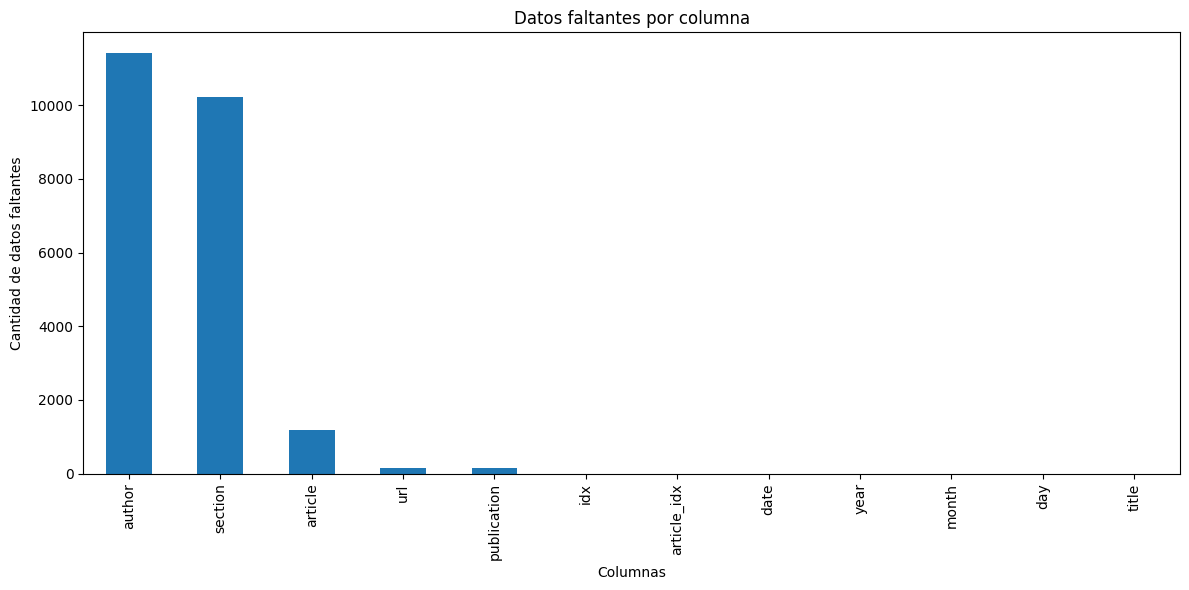

In [ ]:

faltantes = df.isna().sum().sort_values(ascending=False)

faltantes.plot(kind="bar", figsize=(12,6))
plt.ylabel("Cantidad de datos faltantes")
plt.xlabel("Columnas")
plt.title("Datos faltantes por columna")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Conversión de tipo de datos

Este gráfico muestra la cantidad de datos faltantes en cada una de las variables con las que cuenta el dataset.

Las variables que cuentan con la mayor cantidad son _author_ y _section_, en ese orden, las cuales cuentan con más de 10000 datos nulos, lo cual representa más de un 30% de los registros. _article_, por su parte, cuenta con un poco más de 1000 datos faltantes, aproximadamente un 4% del total, y _url_ y _publication_ cuentan ambas con exactamente 141 datos nulos, menos de un 0.5% del total. El resto de variables no cuentan con datos faltantes.

In [5]:
# a fecha
df["date"] = pd.to_datetime(df["date"], format="mixed") # distintos formatos en las fechas
# a numérico
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["month"] = pd.to_numeric(df["month"], errors="coerce")
df["day"] = pd.to_numeric(df["day"], errors="coerce")
# a texto
text_columns = [
    "author",
    "title",
    "article",
    "url",
    "section",
    "publication"
]

df[text_columns] = df[text_columns].astype("string")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   idx          30213 non-null  int64         
 1   article_idx  30213 non-null  int64         
 2   date         30213 non-null  datetime64[ns]
 3   year         30213 non-null  int64         
 4   month        30213 non-null  float64       
 5   day          30213 non-null  int64         
 6   author       18808 non-null  string        
 7   title        30213 non-null  string        
 8   article      29037 non-null  string        
 9   url          30072 non-null  string        
 10  section      19981 non-null  string        
 11  publication  30072 non-null  string        
dtypes: datetime64[ns](1), float64(1), int64(4), string(6)
memory usage: 2.8 MB


In [36]:
# TODO: Analice la cantidad de artículos por medio de prensa

# Tome los 5 medios con más artículos
top_5_publications = df["publication"].value_counts().head(5).reset_index() # ya lo devuelve descendiente, en un dataframe
top_5_publications.columns = [
    "Medio de prensa",
    "Cantidad de artículos"]
top_5_publications

,Medio de prensa,Cantidad de artículos
0,Reuters,9431
1,The New York Times,2840
2,CNBC,2623
3,The Hill,2349
4,People,1528


In [45]:
df_top_5 = df[df["publication"].isin(top_5_publications["Medio de prensa"])].reset_index(drop=True)

## B. Visualización temporal
Genere una gráfica que permita visualizar los artículos de los cinco medios a lo largo del tiempo, con alguna escala temporal adecuada. \
Comente si se identifican momentos de mayor actividad o patrones temporales en la cobertura.

/tmp/ipykernel_35560/280311733.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_5["año_mes"] = df_top_5["date"].dt.to_period("M") # si lo dejo por fecha con día, queda muy ruidoso


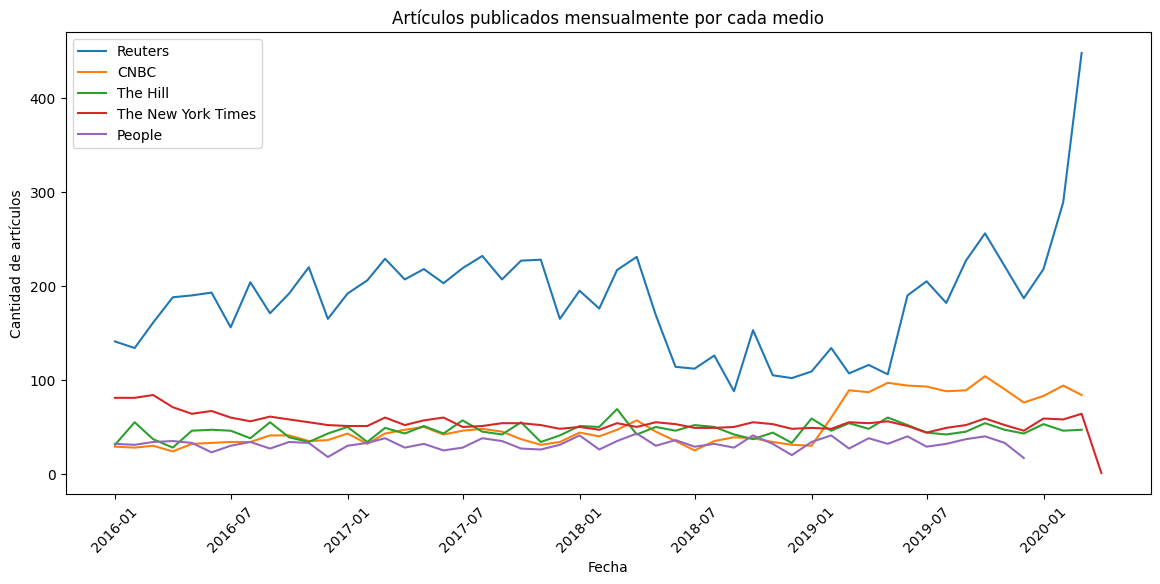

In [8]:
# TODO: Visualización de los artículos de cada medio a lo largo del tiempo
# Preste especial atención al formato de la columna 'date', ya que puede contener diferentes formatos de fecha.

df_top_5["año_mes"] = df_top_5["date"].dt.to_period("M") # si lo dejo por fecha con día, queda muy ruidoso
articulos_por_fecha = (df_top_5
    .groupby(["año_mes", "publication"])
    .size()
    .reset_index(name="Cantidad"))

plt.figure(figsize=(14,6))
for publication in df_top_5["publication"].dropna().unique(): #por si hay NAs

    subset = articulos_por_fecha[
        articulos_por_fecha["publication"] == publication
    ]

    plt.plot(
        subset["año_mes"].dt.to_timestamp(),
        subset["Cantidad"],
        label=publication
    )

plt.xlabel("Fecha")
plt.ylabel("Cantidad de artículos")
plt.title("Artículos publicados mensualmente por cada medio")
plt.legend()
plt.xticks(rotation=45)

plt.show()

Este gráfico muestra la cantidad de artículos que han publicado por mes entre 1016 y 2020 cada uno de los 5 medios de prensa con más artículos publicados en el dataset.

Reuters es el medio con la mayor cantidad de artículos publicados para todo el período. En general cuenta con entre 100 y 250 artículos por mes en casi todo el período, excepto en 2020, donde se ve un crecimiento en las publicaciones que duplican las cifras anteriores.

El resto de medios mantuvo cantidades similares entre sí para todo el período, con valores en general en el entorno de 50 y no mayores a 100. Particularmente, CNBC muestra un aumento en sus publicaciónes luego de comenzado el 2019, con valores alrededor de 100 hasta el final del período.

## C. Limpieza de texto y conteo de palabras
Se provee la función `clean_text(...)` que realiza parte de la normalización del texto. \
**Complete la función** agregando signos de puntuación faltantes y cualquier otra normalización que considere oportuna. \
Compruebe el resultado observando el contenido del DataFrame procesado. Comente todas las transformaciones que haya agregado y justifique.

In [ ]:
raros = chars[
    ~chars["char"].str.match(r"[a-zA-Z0-9\s]", na=False)
]
raros.sort_values("conteo", ascending=False)

In [52]:
import string

string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [60]:
import re
import string

def clean_text(df, column_name):

    # Eliminar encabezado hasta el primer salto de línea
    result = df[column_name].str.replace(
        r"^[^\n]*\n",
        "",
        regex=True
    )

    # Minúsculas
    result = result.str.lower()

    # Reemplazar puntuación y saltos de línea por espacios
    punctuation = re.escape(string.punctuation + "—–¿¡«»")
    result = result.str.replace(
        f"[{punctuation}\\n]",
        " ",
        regex=True
    )

    # Eliminar palabras que contengan caracteres no permitidos
    result = result.str.replace(
        r"\b\S*[^a-zA-Z\sáéíóúüñ]\S*\b",
        "",
        regex=True
    )

    # Eliminar espacios múltiples
    result = result.str.replace(
        r"\s+",
        " ",
        regex=True
    ).str.strip()

    return result

Se quitaron todos los símbolos listados en string.punctuation y sustituyeron por un espacio. Luego se eliminan palabras con caracteres usados fuera del idioma español, ya que esto ayudara a la eficiencia en la predicción de un futuro modelo. Por último, se eliminan múltiples espacios continuos.

In [61]:
df_top_5["CleanText"]=clean_text(df_top_5, "article")


In [62]:
df_top_5[["title", "article", "CleanText"]]


,title,article,CleanText
0,BRIEF-Teva Says Fremanezumab Marketing Authori...,Feb 2 (Reuters) - Teva Pharmaceutical Industri...,feb reuters teva pharmaceutical industries ltd...
1,CMS' Verma says it’s time health care caught u...,The head of the Centers for Medicare and Medic...,the head of the centers for medicare and medic...
2,Uber investor accuses Kalanick of 'undermining...,"Benchmark, the venture capital firm that helpe...",benchmark the venture capital firm that helped...
3,UPDATE 2-Magellan Health bows to Starboard pre...,"(Updates with new first paragraph, adds backgr...",updates with new first paragraph adds backgrou...
4,Bank of Montreal's quarterly earnings beat mar...,"TORONTO, Dec 4 (Reuters) - Bank of Montreal on...",toronto dec reuters bank of montreal on tuesda...
...,...,...,...
18766,Kremlin says patiently waiting for U.S. policy...,MOSCOW (Reuters) - The Kremlin is patiently wa...,moscow reuters the kremlin is patiently waitin...
18767,BRIEF-United Financial Bancorp reports Q1 earn...,April 18 (Reuters) - United Financial Bancorp ...,april reuters united financial bancorp inc uni...
18768,BRIEF-Shoe Zone Decides To Defer Payment Of 8 ...,March 17 (Reuters) - Shoe Zone PLC: * DECISION...,march reuters shoe zone plc decision to defer ...
18769,Charlotte Mayor Lifts Citywide Curfew After Pe...,After a weekend of peaceful protests and demon...,after a weekend of peaceful protests and demon...


In [48]:
#df_top_5[df_top_5["article"].str.contains("\n", na=False)][["title", "article", "CleanText"]]

,title,article,CleanText
50,French drugmaker Servier challenges 331 mln eu...,"LUXEMBOURG, June 6 (Reuters) - French drugmake...",reporting by foo yun chee; editing by susan fe...
55,Foxconn exec: Want to buy back Sharp's headqua...,"SAKAI, Japan, April 2 (Reuters) - Foxconn Vice...",reporting by makiko yamazaki; editing by shr...
60,EMERGING MARKETS-Oil rebound lifts EM stocks t...,"LONDON, May 11 (Reuters) - A sharp rebound in ...",kasolowsky
219,UPDATE 3-British lender RBS to bolster capital...,* State-backed RBS needs about 2 bln stg in ad...,simon jessop; editing by rachel armstrong and ...
305,Reality-star-turned-fraudster highlights the r...,"A combination of low interest rates, tight inv...","american greed "" monday sept. 16 at 10 p.m...."
...,...,...,...
18686,Croatian LNG terminal to go ahead despite low ...,"ZAGREB, Jan 16 (Reuters) - Croatia will press ...",reporting by igor ilic; editing by david evans
18748,Michael Strahan's Clothing Line for JCPenney: ...,Just because Michael Strahan is establishing h...,but like any dad ...
18749,RPT-China's Hubei province reports 242 new cor...,"(Repeats to attach to alerts) BEIJING, Feb 13 ...",coghill
18754,US STOCKS-Wall St jumps in 'schizophrenic' reb...,* Crude oil prices rise 6 pct * Coach jumps af...,editing by nick zieminski


In [63]:
from collections import Counter
import unicodedata as ud
col = "CleanText"
s = df_top_5[col].fillna("").astype(str)
counts = Counter("".join(s))
chars = pd.DataFrame([
    {
        "char": ch,
        "categoria": ud.category(ch),
        "conteo": n
    }
    for ch, n in counts.items()
]).sort_values("conteo", ascending=False)
chars

,char,categoria,conteo
3,,Zs,8142236
1,e,Ll,4687714
6,t,Ll,3493574
9,a,Ll,3317935
14,i,Ll,2963869
...,...,...,...
217,,Cc,1
218,🎀,So,1
219,👑,So,1
220,′,Po,1


## D. Elección de campos de texto
Discuta si conviene trabajar con:
- sólo el cuerpo del artículo,
- sólo el título,
- o una combinación de ambos.

Justifique brevemente su decisión.

Aplicando la misma limpieza sobre el título, se puede trabajar con ambos. Quizás conviene dejar ambas columnas separadas.

## E. Pistas que identifican al medio de prensa
Analice si en el texto aparecen pistas que identifiquen de manera directa al medio de prensa (nombres del medio, URLs, firmas, nombres de secciones, plantillas repetidas, etc.). \
En caso de encontrarlas, comente si considera conveniente eliminarlas o reducir su impacto, y justifique su decisión.

In [ ]:
# TODO: Explore el texto buscando pistas que identifiquen directamente al medio de prensa
# Por ejemplo, busque nombres de medios, URLs, firmas, etc.

Si la finalidad fuera generar un modelo para predecir el medio de prensa, entonces es necesario eliminarlo, de otra forma, simplemente se centraría en buscar en el texto si está escrito dicho medio.
También conviendría eliminarlo en el caso de que distintos medios se centraran cada uno en temas específicos. Si ls finalidad es que el modelo pueda distinguir entre temas según las palabras más repetidas del artículo, si se encuentra el nombre del medio, esto sería casi determinante sobre el tema.

## F. Restricción por sección o período temporal
Evalúe si conviene restringir el análisis a artículos de una misma sección temática o de un período temporal acotado, con el objetivo de reducir el efecto del tema sobre una futura tarea de clasificación por medio. \
No es necesario implementar esta restricción, pero sí discutir sus posibles ventajas y desventajas.

*TODO: Escriba su análisis en el informe.*

# Parte 2: Conteo de Palabras y Visualizaciones

## A. Palabras más frecuentes por medio
Realice una visualización que permita comparar las palabras más frecuentes de cada uno de los cinco medios de prensa. \
Sin necesidad de implementarlo, proponga ideas para modificar esta visualización con el fin de encontrar diferencias entre secciones temáticas, fechas, o tipos de noticias.

In [65]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_words_by_publication(df, text_col="CleanText", pub_col="publication", top_n=10):
    rows = []

    for publication, group in df.groupby(pub_col):
        texts = group[text_col].dropna().astype(str)

        vectorizer = CountVectorizer()
        word_matrix = vectorizer.fit_transform(texts)

        word_counts = word_matrix.sum(axis=0).A1
        words = vectorizer.get_feature_names_out()

        freq_df = pd.DataFrame({
            "publication": publication,
            "word": words,
            "count": word_counts
        })

        freq_df = freq_df.sort_values("count", ascending=False).head(top_n)
        rows.append(freq_df)

    top_words_df = pd.concat(rows, ignore_index=True)

    publications = top_words_df["publication"].unique()
    n_publications = len(publications)

    fig, axes = plt.subplots(
        nrows=n_publications,
        ncols=1,
        figsize=(10, 4 * n_publications)
    )

    if n_publications == 1:
        axes = [axes]

    for ax, publication in zip(axes, publications):
        data = top_words_df[top_words_df["publication"] == publication]
        data = data.sort_values("count", ascending=True)

        ax.barh(data["word"], data["count"])
        ax.set_title(f"Palabras más frecuentes - {publication}")
        ax.set_xlabel("Frecuencia")
        ax.set_ylabel("Palabra")

    plt.tight_layout()
    plt.show()

    return top_words_df

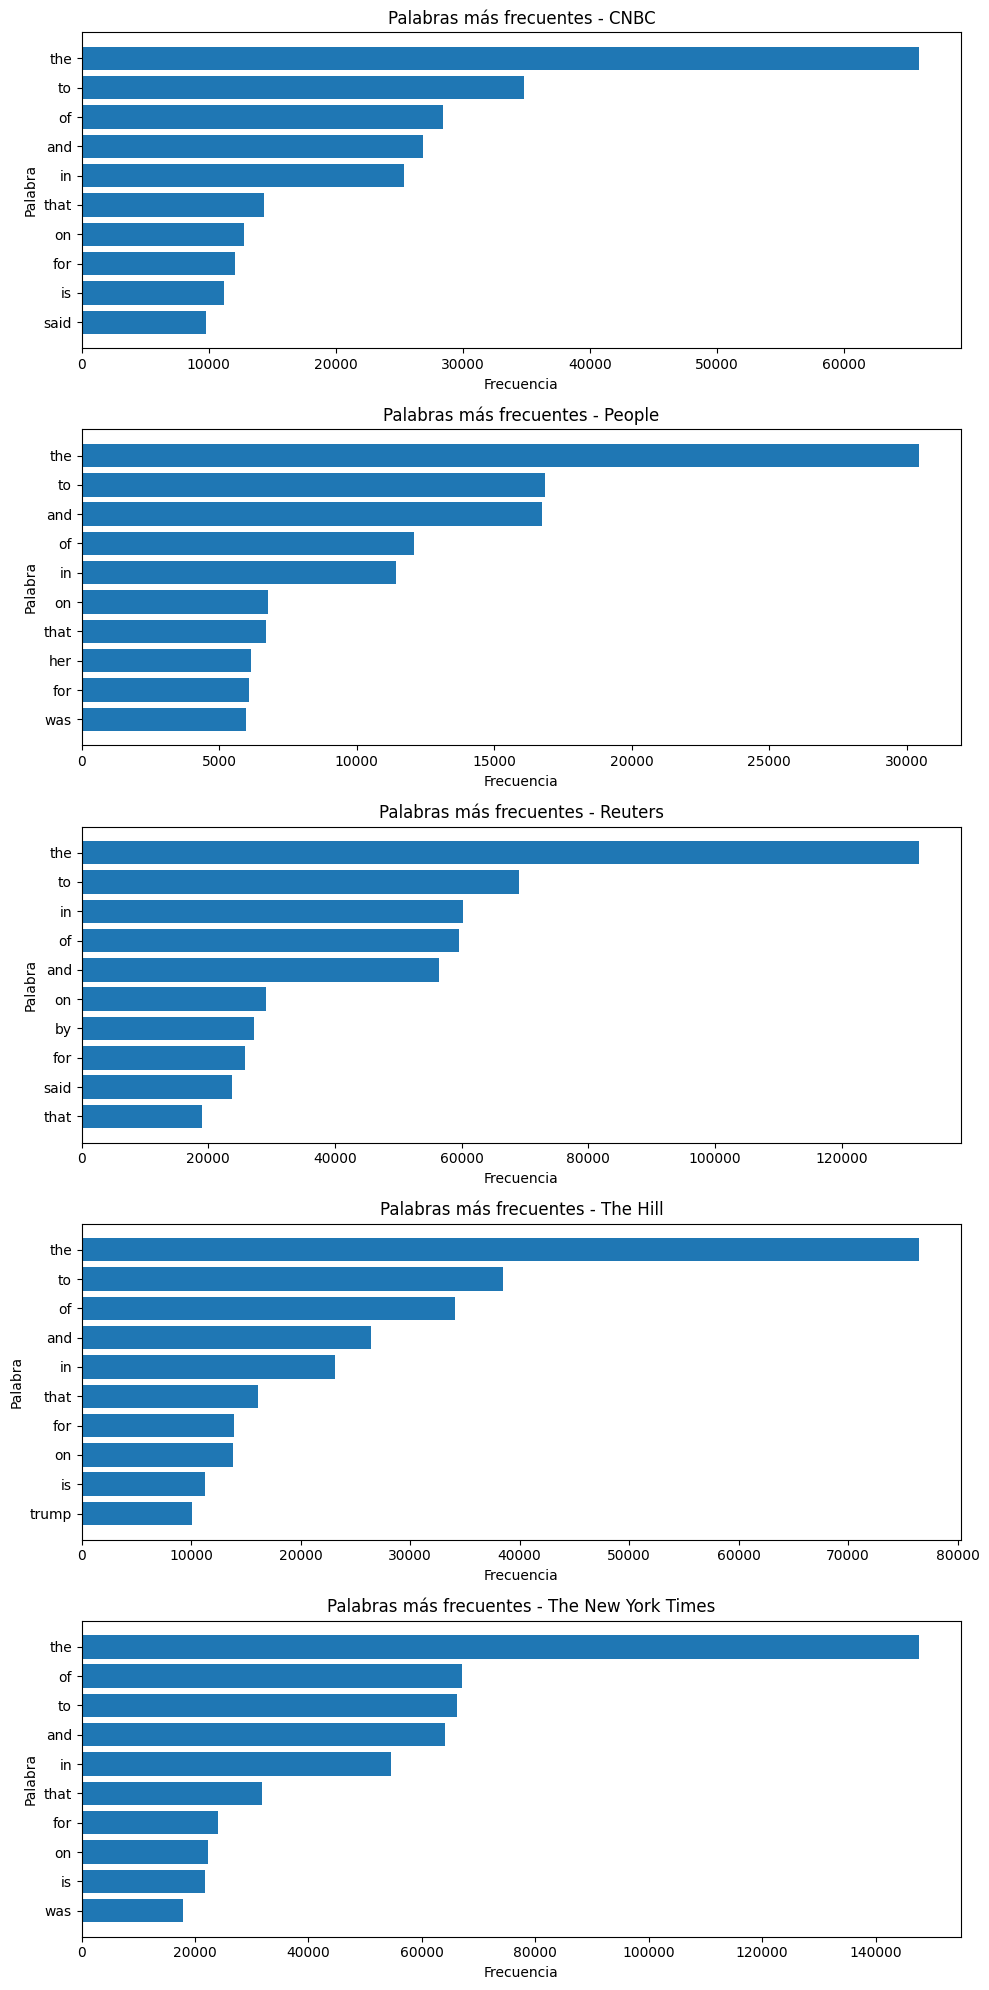

In [68]:
top_words_df = plot_top_words_by_publication(
    df_top_5,
    text_col="CleanText",
    pub_col="publication",
    top_n=10
)
# - ¿Encuentra algún problema en los resultados?


the of to and in that for on is was a by

In [87]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stopwords = list(ENGLISH_STOP_WORDS) + ["s", "u", "say", "said"]

df_top_5["CleanText"] = (
    df_top_5["CleanText"]
    .str.replace(
        r"\b(" + "|".join(stopwords) + r")\b",
        "",
        regex=True
    )
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

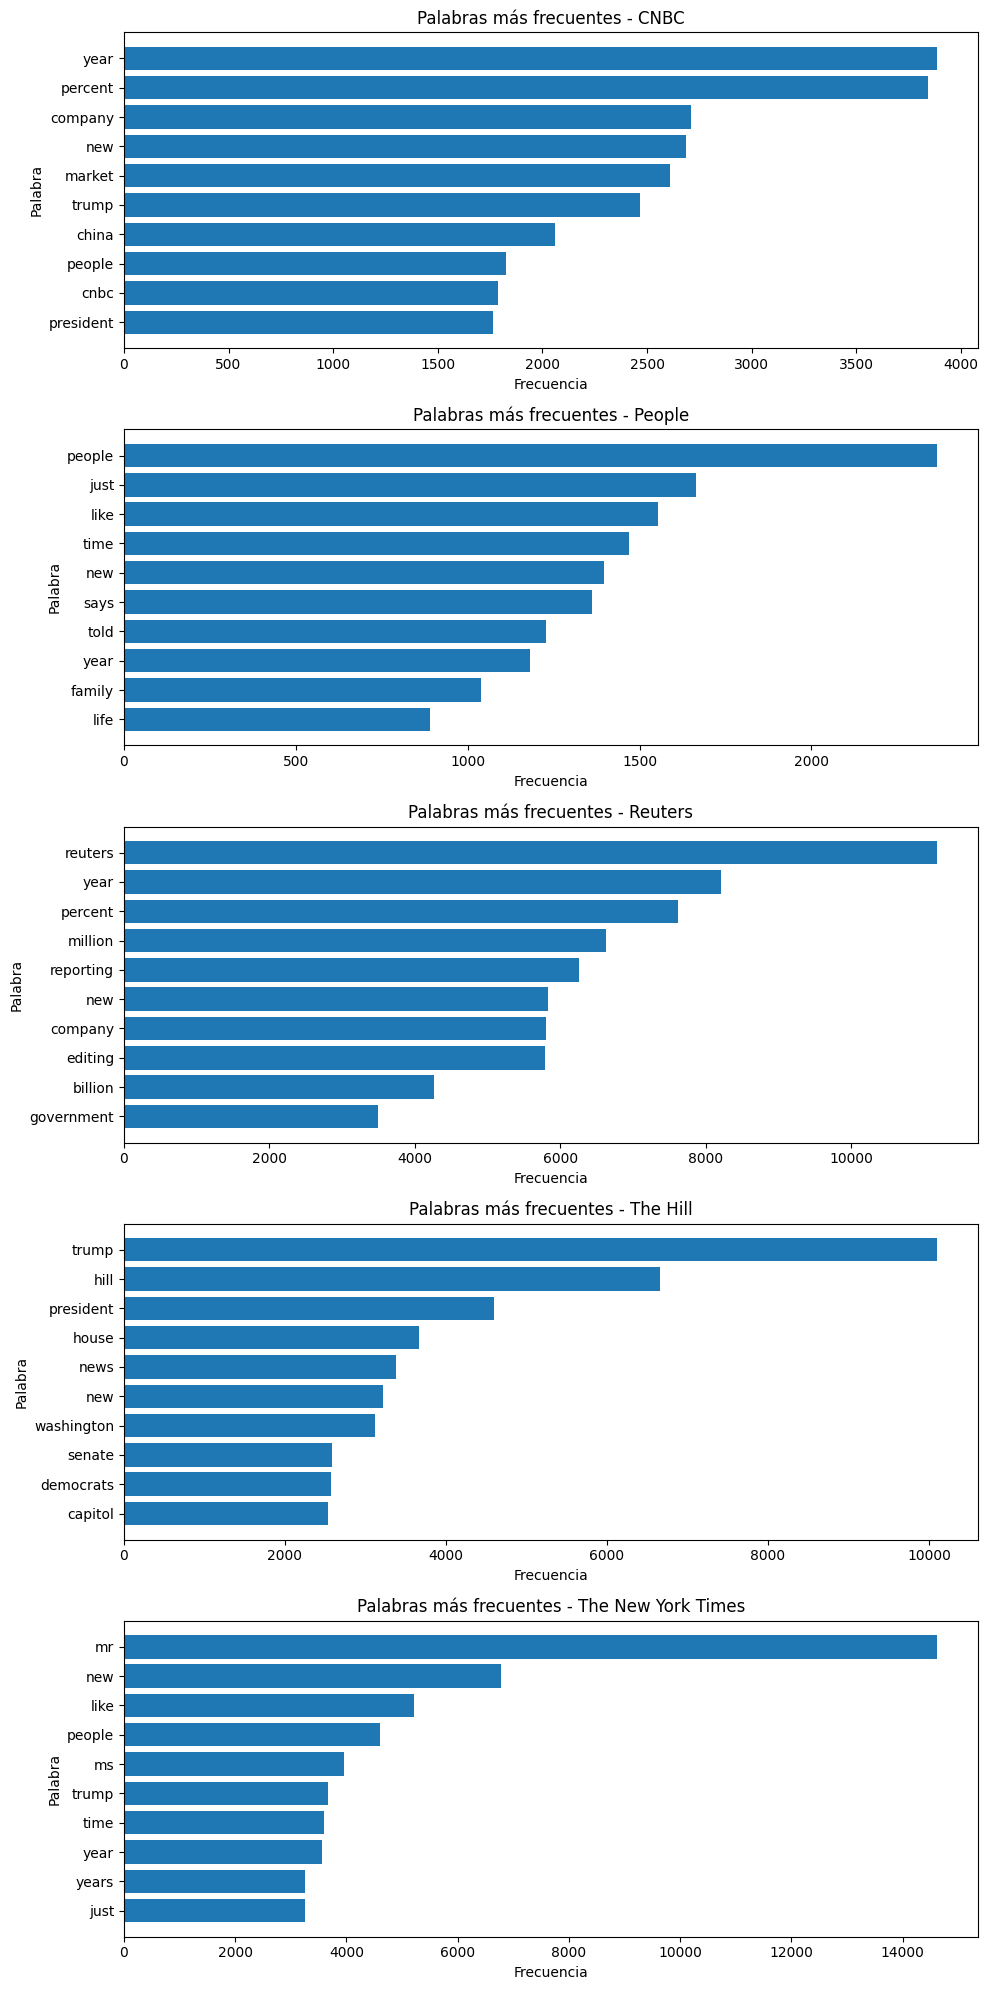

In [81]:
top_words_df = plot_top_words_by_publication(
    df_top_5,
    text_col="CleanText",
    pub_col="publication",
    top_n=10
)

La librería scikit-learn permite listar hasta 318 stopwords o "palabras vacías", las cuales no aportan en general nada de contexto y sirven en su mayoría para dar estructura al texto.

In [82]:
from wordcloud import WordCloud
import math

def plot_wordclouds_by_publication(
    df,
    text_col="CleanText",
    pub_col="publication",
    max_words=100,
    stopwords=None,
    cols=2,
    figsize=(14, 6)
):
    publications = df[pub_col].dropna().unique()
    n_publications = len(publications)
    rows = math.ceil(n_publications / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(figsize[0], figsize[1] * rows))

    # Asegurar que axes siempre sea iterable
    if rows == 1 and cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, publication in enumerate(publications):
        text = " ".join(
            df.loc[df[pub_col] == publication, text_col]
            .dropna()
            .astype(str)
        )

        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color="white",
            stopwords=stopwords,
            max_words=max_words
        ).generate(text)

        axes[i].imshow(wordcloud, interpolation="bilinear")
        axes[i].set_title(f"Word Cloud - {publication}")
        axes[i].axis("off")

    # Ocultar ejes vacíos
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

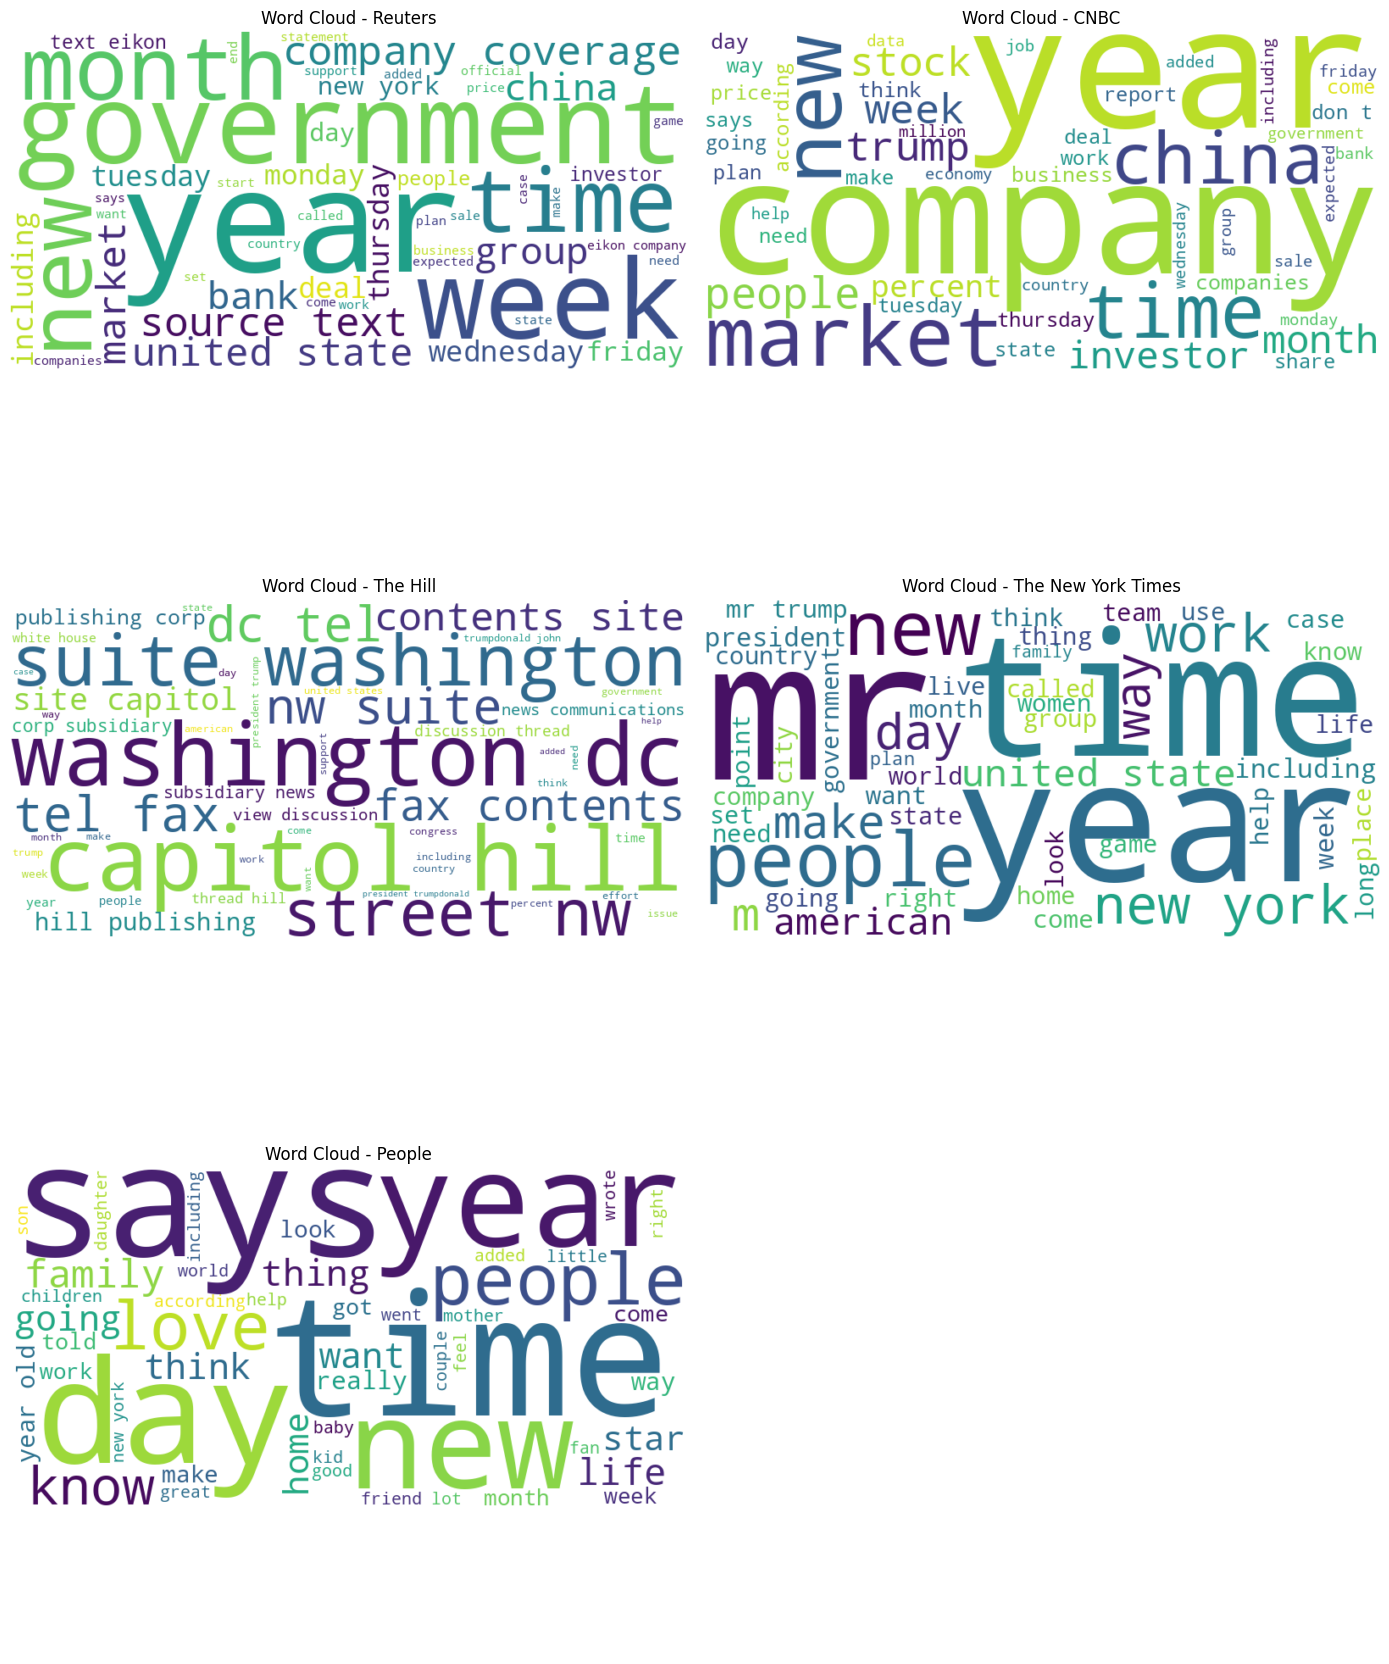

In [88]:
plot_wordclouds_by_publication(
    df_top_5,
    max_words=50
)

## B. Medios con mayor cantidad de palabras
Corra el código que permite encontrar los medios con mayor cantidad de palabras. \
En caso de encontrar algún problema luego de realizar la visualización, comente a qué se debe y proponga formas de resolverlo.

In [ ]:
# TODO: Busque los medios con mayor cantidad de palabras

## C. Matriz de menciones entre medios
Construya una matriz de 5×5, donde cada fila y columna corresponden a un medio de prensa, y la entrada (i,j) contiene la cantidad de veces que el medio *i* menciona al medio *j*. \
\
**Opcional:** genere un grafo dirigido con esa matriz de adyacencia para visualizar las menciones. Puede ser útil la biblioteca `networkx`.

In [ ]:
# TODO: Construya una matriz de 5x5, donde cada fila y columna corresponden a un medio de prensa,
# y la entrada (i,j) contiene la cantidad de veces que el medio "i" menciona al medio "j".

# mentions_matrix = ...


In [ ]:
# Opcional: Genere un grafo dirigido con la matriz de adyacencia para visualizar las menciones.
# Puede ser útil la biblioteca networkx.



## D. Preguntas propuestas
Proponga al menos tres preguntas que se podrían intentar responder a partir de estos datos, y mencione posibles caminos para responderlas, sin implementar nada.

*TODO: Escriba sus preguntas y posibles caminos en el informe.*